# Sector ETF Portfolio Optimisation vs S&P 500
### Walk-forward backtest with Regime-Switching — 11 SPDR Sector ETFs (2007–2024)


## 1. Import libraries and download data

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# The 11 SPDR sector ETFs (one per GICS sector) + S&P 500 benchmark
tickers = ["XLK", "XLF", "XLV", "XLE", "XLI",
           "XLB", "XLY", "XLP", "XLU", "XLRE", "XLC", "SPY", "^VIX"]

# Download daily adjusted close prices (2005-2024)
raw = yf.download(tickers, start="2005-01-01", end="2024-12-31",
                  auto_adjust=True, progress=False)["Close"]

prices = raw.drop(columns=["^VIX"])
vix    = raw["^VIX"]

print(prices.shape)
print(prices.tail())

(5032, 12)
Ticker             SPY        XLB        XLC        XLE        XLF  \
Date                                                                 
2024-12-23  586.186584  41.519794  96.750389  40.344978  47.511101   
2024-12-24  592.702087  41.744301  97.666283  40.686272  48.070400   
2024-12-26  592.741577  41.680855  97.538269  40.652622  48.188148   
2024-12-27  586.502014  41.456348  96.671600  40.647812  47.834908   
2024-12-30  579.809143  40.899956  95.657227  40.643017  47.373730   

Ticker             XLI         XLK        XLP       XLRE        XLU  \
Date                                                                  
2024-12-23  130.947556  118.151154  76.391617  38.928692  36.717144   
2024-12-24  131.970596  119.372017  76.894943  39.187962  36.919907   
2024-12-26  132.068970  119.451431  77.136940  39.245571  36.833008   
2024-12-27  131.085251  117.863312  76.759438  38.928692  36.726807   
2024-12-30  129.767136  116.364532  75.859230  38.746243  36.572330   



## 2. Compute daily returns

In [ ]:
returns = prices.pct_change().dropna(how="all")

# Separate sector ETFs from benchmark
sector_etfs = ["XLK", "XLF", "XLV", "XLE", "XLI",
               "XLB", "XLY", "XLP", "XLU", "XLRE", "XLC"]
ret_sectors = returns[sector_etfs]
ret_spy     = returns["SPY"]

print(ret_sectors.describe().round(4))


Ticker        XLK        XLF        XLV        XLE        XLI        XLB  \
count   5031.0000  5031.0000  5031.0000  5031.0000  5031.0000  5031.0000   
mean       0.0006     0.0004     0.0004     0.0005     0.0005     0.0004   
std        0.0139     0.0186     0.0105     0.0190     0.0132     0.0148   
min       -0.1381    -0.1667    -0.0986    -0.2014    -0.1134    -0.1241   
25%       -0.0054    -0.0064    -0.0044    -0.0082    -0.0054    -0.0066   
50%        0.0011     0.0006     0.0006     0.0008     0.0009     0.0009   
75%        0.0072     0.0075     0.0058     0.0099     0.0067     0.0081   
max        0.1390     0.1646     0.1205     0.1647     0.1265     0.1406   

Ticker        XLY        XLP        XLU       XLRE        XLC  
count   5031.0000  5031.0000  5031.0000  2321.0000  1643.0000  
mean       0.0005     0.0004     0.0004     0.0004     0.0005  
std        0.0138     0.0089     0.0118     0.0132     0.0146  
min       -0.1267    -0.0940    -0.1136    -0.1600    -0.11

## 3. Plot cumulative returns of each sector

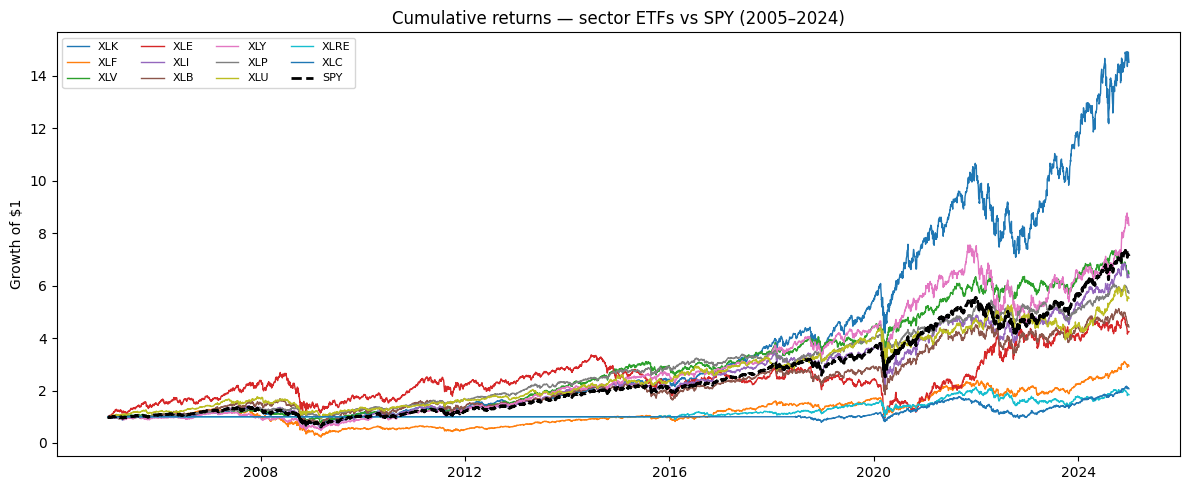

In [ ]:
cum_returns = (1 + ret_sectors.fillna(0)).cumprod()

plt.figure(figsize=(12, 5))
for col in cum_returns.columns:
    plt.plot(cum_returns[col], label=col, linewidth=1)
plt.plot((1 + ret_spy.fillna(0)).cumprod(), label="SPY",
         color="black", linestyle="--", linewidth=2)
plt.title("Cumulative returns — sector ETFs vs SPY (2005–2024)")
plt.ylabel("Growth of $1")
plt.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.savefig("fig1_cumulative.png", dpi=120)
plt.show()


## 4. Optimisation functions

In [ ]:
RISK_FREE = 0.02        # annual risk-free rate
TRADING_DAYS = 252

def min_variance(cov_matrix):
    n = cov_matrix.shape[0]
    w0 = np.ones(n) / n  # start from equal weights
    constraints = {"type": "eq", "fun": lambda w: w.sum() - 1}
    bounds = [(0, 0.30)] * n
    result = minimize(
        lambda w: w @ cov_matrix @ w,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    return result.x

def max_sharpe(mean_returns, cov_matrix):
    n = len(mean_returns)
    rf_daily = (1 + RISK_FREE) ** (1 / TRADING_DAYS) - 1
    w0 = np.ones(n) / n
    constraints = {"type": "eq", "fun": lambda w: w.sum() - 1}
    bounds = [(0, 0.30)] * n
    def neg_sharpe(w):
        port_ret = w @ mean_returns - rf_daily
        port_vol = np.sqrt(w @ cov_matrix @ w)
        return -port_ret / port_vol
    result = minimize(
        neg_sharpe, w0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    return result.x

print("Functions ready.")


Functions ready.


## 4b. Regime detection (KMeans, walk-forward)

In [ ]:
ROLL = 21   # rolling window for features (trading days)

def compute_features(spy_ret, vix_series, end_date, window=504):
    """
    Build a (window, 3) feature matrix for KMeans on data UP TO end_date.
    Features (daily): realised vol (21d), momentum (21d), VIX level.
    """
    spy  = spy_ret.loc[:end_date].iloc[-window:]
    vix_ = vix_series.loc[:end_date].reindex(spy.index).ffill()

    rvol = spy.rolling(ROLL).std() * np.sqrt(252)
    mom  = spy.rolling(ROLL).apply(lambda x: (1 + x).prod() - 1, raw=True)

    feats = pd.DataFrame({'rvol': rvol, 'mom': mom, 'vix': vix_}).dropna()
    return feats, spy.index


def detect_regime(spy_ret, vix_series, end_date, window=504, n_clusters=3, seed=42):
    """
    Fit KMeans on past data, return the regime label for the LAST observation
    (i.e. the regime at rebalancing date).
    Labels: 0=bear, 1=neutral, 2=bull  (sorted by mean momentum of cluster).
    Also returns the full label series for plotting.
    """
    feats, idx = compute_features(spy_ret, vix_series, end_date, window)
    if len(feats) < n_clusters * 10:
        return 1, None, None  # fallback: neutral

    scaler = StandardScaler()
    X = scaler.fit_transform(feats.values)

    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    raw_labels = km.fit_predict(X)

    # Sort clusters by mean momentum → 0=bear, 1=neutral, 2=bull
    cluster_mom = [
        feats['mom'].values[raw_labels == k].mean()
        for k in range(n_clusters)
    ]
    rank = np.argsort(np.argsort(cluster_mom))  # 0,1,2 = bear,neutral,bull
    mapped = np.array([rank[l] for l in raw_labels])

    label_series = pd.Series(mapped, index=feats.index)
    current_regime = int(mapped[-1])
    return current_regime, label_series, feats


REGIME_NAMES  = {0: 'bear', 1: 'neutral', 2: 'bull'}
REGIME_COLORS = {0: '#d62728', 1: '#ff7f0e', 2: '#2ca02c'}
print('Regime detection functions ready.')

Regime detection functions ready.


## 5. Walk-forward backtest (with regime-switching)

In [ ]:
# Get quarterly rebalancing dates (from 2007 onwards)
rebal_dates = ret_sectors.resample("QE").last().index
rebal_dates = rebal_dates[rebal_dates >= "2007-01-01"]

WINDOW = 504       # estimation window: ~2 years
TC     = 0.0010    # 10 basis points transaction cost

# Portfolio daily returns
mv_returns  = []
ms_returns  = []
rs_returns  = []   # regime-switching portfolio
dates_list  = []

# Regime log (one label per rebalancing date)
regime_log = {}    # date -> regime int

prev_w_mv = None
prev_w_ms = None
prev_w_rs = None

for i in range(len(rebal_dates) - 1):
    t_start = rebal_dates[i]
    t_end   = rebal_dates[i + 1]

    window_data = ret_sectors.loc[:t_start].iloc[-WINDOW:]
    valid_etfs  = window_data.columns[window_data.notna().all()]
    window_data = window_data[valid_etfs]

    if len(valid_etfs) < 3:
        continue

    # ── Estimate parameters ──────────────────────────────────────────────
    mu  = window_data.mean().values
    cov = window_data.cov().values

    # ── Detect regime (walk-forward, no look-ahead) ───────────────────────
    regime, _, _ = detect_regime(ret_spy, vix, t_start, window=WINDOW)
    regime_log[t_start] = regime

    # ── Optimise ──────────────────────────────────────────────────────────
    w_mv = min_variance(cov)
    w_ms = max_sharpe(mu, cov)

    # Regime-switching: bull → Max-Sharpe, neutral/bear → Min-Variance
    w_rs = w_ms.copy() if regime == 2 else w_mv.copy()

    # ── Transaction costs ────────────────────────────────────────────────
    def _tc(prev_w, new_w, valid):
        if prev_w is None:
            return TC
        old = pd.Series(prev_w).reindex(valid, fill_value=0).values
        return 0.5 * np.abs(new_w - old).sum() * TC

    tc_mv = _tc(prev_w_mv, w_mv, valid_etfs)
    tc_ms = _tc(prev_w_ms, w_ms, valid_etfs)
    tc_rs = _tc(prev_w_rs, w_rs, valid_etfs)

    prev_w_mv = pd.Series(w_mv, index=valid_etfs)
    prev_w_ms = pd.Series(w_ms, index=valid_etfs)
    prev_w_rs = pd.Series(w_rs, index=valid_etfs)

    # ── Apply weights to next quarter ────────────────────────────────────
    next_quarter = ret_sectors.loc[t_start:t_end, valid_etfs].iloc[1:]

    for day_idx, (date, day_ret) in enumerate(next_quarter.iterrows()):
        r = day_ret.fillna(0).values
        first = day_idx == 0
        mv_returns.append(r @ w_mv - (tc_mv if first else 0))
        ms_returns.append(r @ w_ms - (tc_ms if first else 0))
        rs_returns.append(r @ w_rs - (tc_rs if first else 0))
        dates_list.append(date)

# Build series
mv_ret  = pd.Series(mv_returns, index=dates_list)
ms_ret  = pd.Series(ms_returns, index=dates_list)
rs_ret  = pd.Series(rs_returns, index=dates_list)
spy_oos = ret_spy.loc[mv_ret.index[0]: mv_ret.index[-1]]

regime_series = pd.Series(regime_log).sort_index()

print(f"Backtest: {mv_ret.index[0].date()} to {mv_ret.index[-1].date()}")
print(f"Number of trading days: {len(mv_ret)}")
print(f"Regime distribution:\n{regime_series.map(REGIME_NAMES).value_counts()}")

Backtest: 2007-04-03 to 2024-12-30
Number of trading days: 4446
Regime distribution:
neutral    37
bull       18
bear       16
Name: count, dtype: int64


## 6. Plot cumulative performance

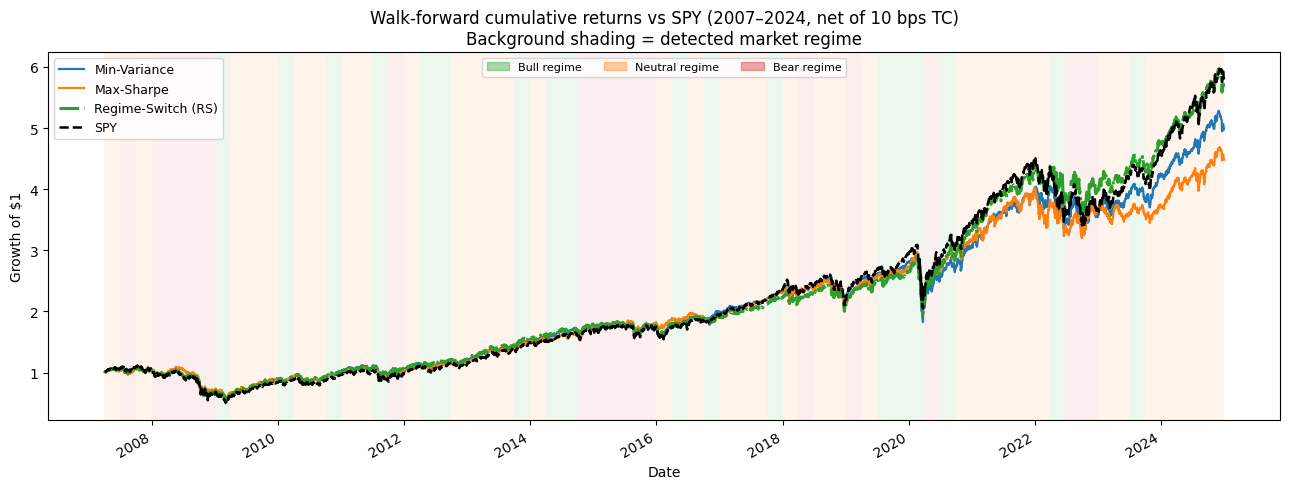

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

# ── Shade background by regime ───────────────────────────────────────────
rebal_list = regime_series.index.tolist()
for j, rd in enumerate(rebal_list):
    r_end = rebal_list[j + 1] if j + 1 < len(rebal_list) else mv_ret.index[-1]
    ax.axvspan(rd, r_end, alpha=0.08, color=REGIME_COLORS[regime_series[rd]], lw=0)

# ── Portfolio curves ─────────────────────────────────────────────────────
(1 + mv_ret).cumprod().plot(ax=ax, label='Min-Variance', linewidth=1.6)
(1 + ms_ret).cumprod().plot(ax=ax, label='Max-Sharpe',   linewidth=1.6)
(1 + rs_ret).cumprod().plot(ax=ax, label='Regime-Switch (RS)', linewidth=2.2, linestyle='-.')
(1 + spy_oos).cumprod().plot(ax=ax, label='SPY', color='black', linestyle='--', linewidth=1.8)

# Legend for regimes
patches = [mpatches.Patch(color=REGIME_COLORS[k], alpha=0.4, label=f'{REGIME_NAMES[k].capitalize()} regime')
           for k in [2, 1, 0]]
leg1 = ax.legend(loc='upper left', fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=patches, loc='upper center', fontsize=8, ncol=3)

ax.set_title('Walk-forward cumulative returns vs SPY (2007–2024, net of 10 bps TC)\nBackground shading = detected market regime')
ax.set_ylabel('Growth of $1')
plt.tight_layout()
plt.savefig('fig2_walk_forward.png', dpi=120)
plt.show()

## 7a. Performance metrics

In [ ]:
def performance_metrics(ret_series, name):
    r = ret_series.dropna()
    n = len(r)
    ann_return = (1 + r).prod() ** (TRADING_DAYS / n) - 1
    ann_vol    = r.std() * np.sqrt(TRADING_DAYS)
    sharpe     = (ann_return - RISK_FREE) / ann_vol
    cum        = (1 + r).cumprod()
    max_dd     = (cum / cum.cummax() - 1).min()
    calmar     = ann_return / abs(max_dd) if max_dd != 0 else np.nan
    return pd.Series({
        'Ann. Return (%)':  round(ann_return * 100, 2),
        'Ann. Vol (%)':     round(ann_vol * 100, 2),
        'Sharpe Ratio':     round(sharpe, 3),
        'Max Drawdown (%)': round(max_dd * 100, 2),
        'Calmar Ratio':     round(calmar, 3),
    }, name=name)

metrics = pd.concat([
    performance_metrics(mv_ret,  'Min-Variance'),
    performance_metrics(ms_ret,  'Max-Sharpe'),
    performance_metrics(rs_ret,  'Regime-Switch'),
    performance_metrics(spy_oos, 'SPY'),
], axis=1)

print(metrics)
metrics.to_csv('performance_metrics.csv')

                  Min-Variance  Max-Sharpe  Regime-Switch     SPY
Ann. Return (%)          9.530       8.870         10.280  10.420
Ann. Vol (%)            19.290      18.820         18.950  19.860
Sharpe Ratio             0.390       0.365          0.437   0.424
Max Drawdown (%)       -52.650     -47.320        -49.140 -55.190
Calmar Ratio             0.181       0.187          0.209   0.189


## 7b. Performance breakdown by regime

We split the OOS period by the detected regime at each quarter and compute
Sharpe ratios separately. This answers: *does the regime-switching portfolio
actually outperform in the regimes it is designed for?*

In [ ]:
# Map each trading day to its regime (last rebalancing date before that day)
day_regime = pd.Series(index=mv_ret.index, dtype=float)
for j, rd in enumerate(rebal_list):
    r_end = rebal_list[j + 1] if j + 1 < len(rebal_list) else mv_ret.index[-1]
    day_regime.loc[rd:r_end] = regime_series[rd]

results = []
for regime_val, regime_name in REGIME_NAMES.items():
    mask = day_regime == regime_val
    if mask.sum() < 20:
        continue
    row = {'Regime': regime_name, 'Days': int(mask.sum())}
    for label, series in [('Min-Var', mv_ret), ('Max-Sharpe', ms_ret),
                           ('Regime-Switch', rs_ret), ('SPY', spy_oos)]:
        s = series.reindex(mask.index)[mask].dropna()
        ann_r = (1 + s).prod() ** (252 / len(s)) - 1
        ann_v = s.std() * np.sqrt(252)
        row[f'Sharpe ({label})'] = round((ann_r - RISK_FREE) / ann_v, 3) if ann_v > 0 else np.nan
    results.append(row)

regime_breakdown = pd.DataFrame(results).set_index('Regime')
print(regime_breakdown)
regime_breakdown.to_csv('regime_breakdown.csv')

         Days  Sharpe (Min-Var)  Sharpe (Max-Sharpe)  Sharpe (Regime-Switch)  \
Regime                                                                         
bear     1011            -0.019                0.086                  -0.036   
neutral  2302             1.218                0.870                   1.204   
bull     1133            -0.151                0.004                   0.007   

         Sharpe (SPY)  
Regime                 
bear           -0.034  
neutral         1.202  
bull           -0.094  


## 8. Drawdown chart

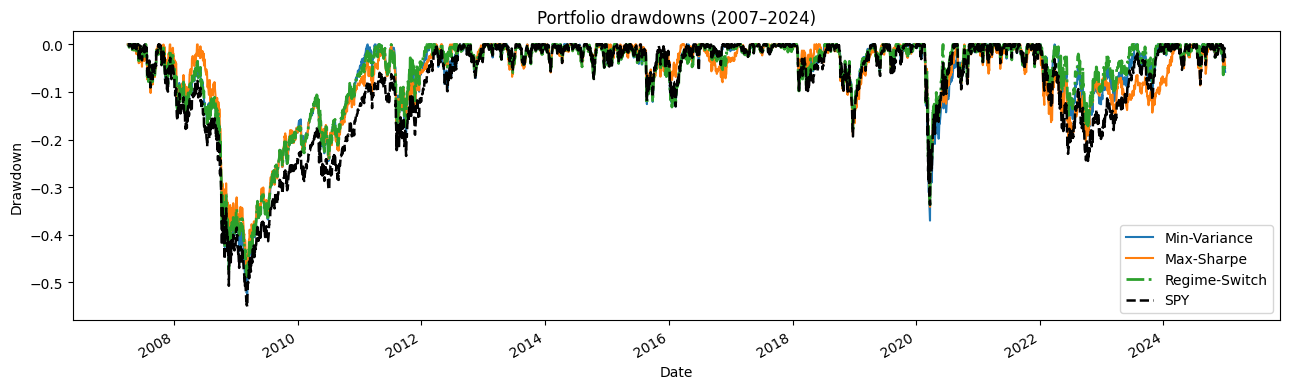

In [ ]:
def drawdown(r):
    cum = (1 + r).cumprod()
    return cum / cum.cummax() - 1

fig, ax = plt.subplots(figsize=(13, 4))
drawdown(mv_ret).plot(ax=ax,  label='Min-Variance', linewidth=1.5)
drawdown(ms_ret).plot(ax=ax,  label='Max-Sharpe',   linewidth=1.5)
drawdown(rs_ret).plot(ax=ax,  label='Regime-Switch', linewidth=2.0, linestyle='-.')
drawdown(spy_oos).plot(ax=ax, label='SPY', color='black', linestyle='--', linewidth=1.8)
ax.set_title('Portfolio drawdowns (2007–2024)')
ax.set_ylabel('Drawdown')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_drawdowns.png', dpi=120)
plt.show()

## 9. In-sample vs out-of-sample: the look-ahead trap




In [ ]:
# In-sample: estimate on full history, apply to same period (WRONG)
common_etfs = ret_sectors.dropna(axis=1).columns.tolist()
ret_full = ret_sectors[common_etfs].dropna()

mu_full  = ret_full.mean().values
cov_full = ret_full.cov().values

w_mv_is = min_variance(cov_full)
w_ms_is = max_sharpe(mu_full, cov_full)

is_mv = pd.Series(ret_full.values @ w_mv_is, index=ret_full.index)
is_ms = pd.Series(ret_full.values @ w_ms_is, index=ret_full.index)
is_spy = ret_spy.reindex(ret_full.index).fillna(0)

# Compare Sharpe ratios
is_metrics = pd.concat([
    performance_metrics(is_mv,  "Min-Var (in-sample)"),
    performance_metrics(is_ms,  "Max-Sharpe (in-sample)"),
    performance_metrics(is_spy, "SPY"),
], axis=1)

print("=== IN-SAMPLE (look-ahead biased) ===")
print(is_metrics)
print()
print("=== OUT-OF-SAMPLE (walk-forward, honest) ===")
print(metrics)

gap = pd.DataFrame({
    "Sharpe in-sample":    is_metrics.loc["Sharpe Ratio"],
    "Sharpe walk-forward": metrics.loc["Sharpe Ratio"],
}).dropna()
gap["Gap"] = (gap["Sharpe in-sample"] - gap["Sharpe walk-forward"]).round(3)
print()
print("=== LOOK-AHEAD GAP ===")
print(gap)
gap.to_csv("sharpe_gap.csv")


=== IN-SAMPLE (look-ahead biased) ===
                  Min-Var (in-sample)  Max-Sharpe (in-sample)     SPY
Ann. Return (%)                10.190                  11.360  10.340
Ann. Vol (%)                   18.500                  15.610  19.040
Sharpe Ratio                    0.443                   0.599   0.438
Max Drawdown (%)              -52.530                 -41.620 -55.190
Calmar Ratio                    0.194                   0.273   0.187

=== OUT-OF-SAMPLE (walk-forward, honest) ===
                  Min-Variance  Max-Sharpe  Regime-Switch     SPY
Ann. Return (%)          9.530       8.870         10.280  10.420
Ann. Vol (%)            19.290      18.820         18.950  19.860
Sharpe Ratio             0.390       0.365          0.437   0.424
Max Drawdown (%)       -52.650     -47.320        -49.140 -55.190
Calmar Ratio             0.181       0.187          0.209   0.189

=== LOOK-AHEAD GAP ===
     Sharpe in-sample  Sharpe walk-forward    Gap
SPY             0.438     